# Laboratorio 2 - Parte 2. Modelos no paramétricos - regresión



In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [ ]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L02.02", varname="student");

In [ ]:
student = session.Session(init.endpoint).login(course_id=init.course_id, lab_id='L02.02', google_token=google_token)

In [4]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab2 import *
_, x, y = part_2()
y = y.reshape(np.size(y), 1)

## Tarea 1: Exploración de datos

Para el problema de regresion usaremos la base de datos 'The California Housing Dataset', cuya descripción [pueden encontrarla aqui](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html). La información ya esta cargada dentro del notebook

In [5]:
print("muestra de los 3 primeros renglones de x:\n", x[0:3, :])
print("muestra de los 3 primeros renglones de y:\n", y[0:3])
print ("Qué información nos brinda el resultado de esta instrucción?", x.shape[0])
print ("Qué información nos brinda el resultado de esta instrucción?", x.shape[1])
print ("Qué información nos brinda el resultado de esta instrucción?", len(np.unique(y)))

muestra de los 3 primeros renglones de x:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]]
muestra de los 3 primeros renglones de y:
 [[4.526]
 [3.585]
 [3.521]]
Qué información nos brinda el resultado de esta instrucción? 20640
Qué información nos brinda el resultado de esta instrucción? 8
Qué información nos brinda el resultado de esta instrucción? 3842


En los problemas de regresión, es muy útil explorar la distribución de la variable objetivo. Nuestro primer ejercicio consiste en:
1. visualizar un histograma de la variable. Vamos a realizar el histograma con 20 "cajones".
2. Usar el histograma para confirmar como estan distribuidos los datos

Pistas:
1. explorar la documentación de [plt.hist](https://matplotlib.org/3.3.1/api/_as_gen/matplotlib.pyplot.hist.html). Maneje los valores por defecto.

**NOTA**
Se quiere incentivar la lecutra de la documentación de las librerías, se debe hacer llamado explícito al parámetro a usar. Ejemplo si se necesita usar el parámetro `density`, se debe llamar como `plt.hist(density=True ....)`

In [ ]:
#ejercicio de código
def plot_hist_20(Y):
    """función que grafica el histograma de la variable 'Y'
        teniendo como valor fijo 20 en el parámetro que controla
        el número de "cajones"

        No retorna nada
    """
   plt...


    return

In [9]:
## TEACHER DEFINEGRADER
def grader_01(functions,variables, caller_userid):
    import numpy as np
    import matplotlib.pyplot as plt

    # Crear una función auxiliar para graficar un histograma
    def t_plot_hist_20(Y):
        plt.hist(Y, bins=20)
        plt.title("t_plot_hist_20")
        return None

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    # Obtener la función definida por el usuario
    s_plot_hist_20 = namespace['plot_hist_20']
    if s_plot_hist_20 is None:
        raise ValueError("La función 'plot_hist_20' no está definida en las entradas.")

    # Datos de prueba
    output_target = np.random.randint(0, 10, size=100)

    # Obtener información del histograma de la primera función
    t_plot_hist_20(output_target)
    ax1 = plt.gca()
    t_bars = len([rect.get_x() for rect in ax1.patches])
    #t_bars = [rect.get_height() for rect in ax1.patches]
    plt.clf()  # Limpiar después de cada gráfico

    # Obtener información del histograma de la segunda función
    s_plot_hist_20(output_target)
    ax2 = plt.gca()
    s_bars = len([rect.get_x() for rect in ax2.patches])
    #s_bars = [rect.get_height() for rect in ax2.patches]
    plt.clf()

    # Comparar los resultados
    msg = "Testing your code.<br/><br/>"
    if t_bars != s_bars:
        msg += f"""
        <b>Incorrect estimation of data dimensions</b><br/>
        Expecting result with BINS <pre>{t_bars}</pre> <br/>
        but got <pre>{s_bars}</pre><br/>\n
        """
        return 0, msg

    msg += "<b>Bins Match</b> ✅"
    return 5, msg


# Ejemplo de uso:
source_functions_names_01 = ['plot_hist_20']
source_variables_names_01 = []

In [6]:
## TEACHER
def plot_hist_20(Y):
    plt.hist(Y, bins = 20)
    plt.title("t_plot_hist_20")
    return None

In [7]:
## TEACHER
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L02.02", varname="teacher");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [10]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_01", source_functions_names_01, source_variables_names_01, locals())

<Figure size 640x480 with 0 Axes>

In [11]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L02.02", 'T1',
                  inspect.getsource(grader_01), 'grader_01',
                  source_functions_names_01, source_variables_names_01)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T1');

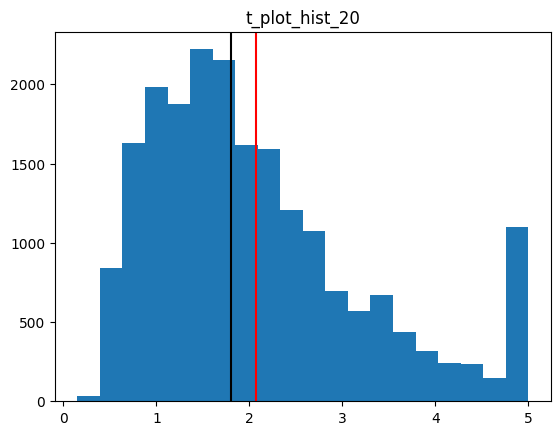

In [14]:
# ver el histograma!
plot_hist_20(y)
# vamos realizar la representacion de la media y mediana
plt.axvline(y.mean(), c = 'r')
plt.axvline(np.median(y), c = 'k')
plt.show()

In [15]:
#@title Pregunta Abierta
#@markdown Evaluando **solo** el histograma, ¿qué tan bien representa la media de y a todo el posible rango de valores de la variable objetivo?
respuesta = "" #@param {type:"string"}

## Tarea 2: K-Vecinos más cercanos para regresión.

Vamos a implementar ahora el modelo KNN para un problema de regresión.

Las mismas pistas de nuestro laboratorio anterior son de utilidad para implementar el algoritmo.

1. Para el cáculo de la distancia entre vectores existen varias opciones:
    1. usar la función la distancia entre matrices `scipy.spatial.distance.cdist`([Ejemplo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html#scipy.spatial.distance.cdist))--esta puede ser usada directamente como `cdist(...)`. Entiende la salida de esta función. Al usarla, se logra un rendimiento superior.
    2. usar la función la distancia euclidiana `scipy.spatial.distance.euclidean`([Ejemplo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html))--pueder acceder a ella directamente como `euclidean`. Aca debe pensar en un algoritmo elemento a elemento, por lo tanto menos eficiente.
2. También serán de utilidad las funciones `np.sort` y `np.argsort`.
3. ¿Cuál es la única diferencia entre el knn para clasificación y regresión? en lugar de la moda, que metodo debemos usar?

In [ ]:
#ejercicio de código
def knn_regresion(k, X_train, Y_train, X_test):
    """ Función que implementa el modelo de K-Vecino mas cercanos
        para regresión

    k (int): valor de vecinos a usar
    X_train: es la matriz con las muestras de entrenamiento
    Y_train: es un vector con los valores de salida pra cada una de las muestras de entrenamiento
    X_test: es la matriz con las muestras de validación

    retorna: las estimaciones del modelo KNN para el conjunto X_test
             esta matriz debe tener un shape de [row/muestras de X_test]
             y las distancias de X_test respecto a X_train, estan matrix
             debe tener un shape de [rows de X_test, rows X_train]
             lo que es lo mismo [muestras de X_test, muestras de X_train]
    """

    from scipy.spatial import distance

    distancias = ...
    Y_est = ...

    #Tener en cuenta que una implementación óptima no requiere ciclos for
    return (Y_est, distancias)

In [19]:
## TEACHER DEFINEGRADER
def grader_02(functions, variables, caller_userid):
    import numpy as np
    from scipy.spatial.distance import cdist, euclidean
    from scipy.spatial import distance

    def t_knn_regresion(k, X_train, Y_train, X_test):
      if k > X_train.shape[0]:
          print("k no puede ser menor que las muestras de entrenamiento")
          return(None)
      N = X_test.shape[0]
      distancia = cdist(X_test,X_train)
      index = np.argsort(distancia,axis=1)[:,0:k]
      temp = np.tile(Y_train.reshape(-1,1), (1, N)).transpose()
      Y_est = np.mean(np.take_along_axis(temp, index, axis=1),axis=1)
      return (Y_est, distancia)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_knn_regresion = namespace['knn_regresion']

    msg = "testing your code with 10 random data points<br/>"
    for _ in range(10):

        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        xtrains = np.random.randn(input_n,input_dim)
        ytrains = np.random.randint(0, 1, size=input_n)
        xtests = np.random.randn(int(input_n/2),input_dim)
        k = np.random.randint(5)+1
        t_model, t_distances = t_knn_regresion(k, xtrains, ytrains, xtests)
        s_model, s_distances = s_knn_regresion(k, xtrains, ytrains, xtests)

        msg = ""

        if t_model.shape[0]!=s_model.shape[0]:
          msg += f"""
          <b>Incorrect dimension.</b> <br/>
          Expecting result <pre>{t_model.shape[0]}</pre> <br/>
          but got <pre>{s_model.shape[0]}</pre><br/>\n
          """
          return 0, msg


        # check distances shape
        if t_distances.shape!=s_distances.shape:
          msg += f"""
          <b>Incorrect distance matrix shape</b>
          for <tt>n_samples_train</tt>={input_n} and <tt>n_samples_test</tt>={int(input_n/2)}<hr/>
          Expecting result <pre>{t_distances.shape}</pre> <br/>
          but got <pre>{s_distances.shape}</pre><br/>\n
          """
          return 0, msg

        # check model predictions
        if not np.array_equal(t_model, s_model):
            msg += f"""
            <b>Incorrect prediction</b>
            for test samples<hr/>
            Expecting result <pre>{t_model}</pre> <br/>
            but got <pre>{s_model}</pre><br/>\n
            """
            return 0, msg

    return 5, msg+'<b>correct</b> ✅'

source_functions_names_02 = ['knn_regresion']
source_variables_names_02 = []

In [36]:
## TEACHER
def knn_regresion(k, X_train, Y_train, X_test):
    from scipy.spatial import distance

    N = X_test.shape[0]
    distancias = distance.cdist(X_test,X_train)
    Y_est = np.zeros(N)

    for i in range(len(X_test)):
      aux = Y_train[np.argsort(distancias[i])[:k]]
      Y_est[i]=sum(aux[:k])/k

    return (Y_est, distancias)

In [37]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_02", source_functions_names_02, source_variables_names_02, locals())

In [22]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L02.02", 'T2',
                  inspect.getsource(grader_02), 'grader_02',
                  source_functions_names_02, source_variables_names_02)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T2');

## Tarea 3: Evaluar modelo K-Vecinos

Ahora vamos a probar nuestro algoritmo. Antes de ello, definos la función para calcular el error

In [23]:
def MAPE(Y_est,Y):
    """Mean Absolute Percentage Error para los problemas de regresión
    Y_est: numpy array con los valores estimados
    Y: numpy array con las etiquetas verdaderas
    retorna: mape
    """
    N = np.size(Y)
    epsilon = 1e-10  # Pequeño valor para evitar división por cero
    mape = np.sum(abs((Y_est.reshape(N, 1) - Y.reshape(N, 1)) / (Y.reshape(N, 1) + epsilon))) / N
    return mape

Vamos a crear la función para experimentar.

En el ejercicio de código, se puede observar que usamos nuevamente la funciónes de la libreria **sklearn**:

1. [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para normalizar.

2. [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Para dividir el conjunto de datos. Entiende como estamos usando esta función y completa el codigo para realizar 5 particiones.

In [ ]:
#Ejercicio de código
def experimentar (ks, X, Y):
    """Función que realiza los experimentos con knn usando
       una estrategia de validacion entrenamiento y pruebas

    ks: List[int/float] lista con los valores de k-vecinos a usar
    X: matriz de numpy conjunto con muestras y caracteristicas
    Y: vector de numpy con los valores a predecir
    retorna: dataframe con los resultados, debe contener las siguientes columnas:
        - los k-vecinos, el error-mape medio de prueba, la desviacion estandar del error-mape
    """

    resultados = pd.DataFrame()
    idx = 0
    # iteramos sobre la lista de k's
    for k in ks:

        # iteramos para validar
        # sobre las particiones
        # ¿que numero debemos asignar para lograr las particiones?
        for j in range(...):
            # dividimos usando la función
            Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y)
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain= scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            Yest, _ = ...(...)
            errorTest = MAPE(...,...)

            resultados.loc[idx,'k-vecinos'] = k
            resultados.loc[idx,'error de prueba'] = ...
            #asignamos la particion
            resultados.loc[idx, 'particion'] = j
            idx+=1

    return (resultados)

In [26]:
## TEACHER DEFINEGRADER
def grader_03(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split


    def t_experimentar(ks, X, Y):
        resultados = pd.DataFrame()
        idx = 0
        # iteramos sobre la lista de k's
        for k in ks:

            # iteramos para validar
            # sobre las particiones
            # ¿que numero debemos asignar para lograr las particiones?
            for j in range(5):
                # dividimos usando la función
                Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y, random_state=0, test_size=0.2)
                scaler = StandardScaler()
                scaler.fit(Xtrain)
                Xtrain= scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                Yest, _ =  knn_regresion(k, Xtrain, Ytrain, Xtest)
                errorTest = MAPE(Yest,Ytest)

                resultados.loc[idx,'k-vecinos'] = k
                resultados.loc[idx,'error en conjunto de prueba'] = errorTest
                #asignamos la particion
                resultados.loc[idx, 'repeticion'] = j
                idx+=1
        return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar = namespace['experimentar']
    s_knn_regresion = namespace['knn_regresion']
    MAPE = namespace['MAPE']

    msg =  "testing your code with random data points<br/>\n"

    ks = [1, 3, 5]

    for _ in range(10):  # Puedes ajustar el número de iteraciones según sea necesario
        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        X = np.random.rand(input_n, input_dim)
        y = np.random.randint(0, 1, size=input_n)

        # Validación de datos: evitar NaN o divisiones por cero
        if np.any(np.isnan(X)) or np.any(np.isnan(y)):
            msg += "Invalid data (NaN). Retrying.<br/>\n"
            continue
        if np.all(y == y[0]):
            # msg += "A uniform dataset was generated. Retrying.<br/>\n"
            continue

        t_resultados = t_experimentar(ks, X, y).values
        s_resultados = s_experimentar(ks, X, y).values

        if not np.allclose(t_resultados, s_resultados):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_03 = ['experimentar','knn_regresion','MAPE']
source_variables_names_03 = []

In [27]:
## TEACHER
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def experimentar (ks, X, Y):
    resultados = pd.DataFrame()
    idx = 0
    # iteramos sobre la lista de k's
    for k in ks:
        for j in range(5):
            # dividimos usando la función
            Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y, random_state=0, test_size=0.2)
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain= scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            Yest, _ =  knn_regresion(k, Xtrain, Ytrain, Xtest)
            errorTest = MAPE(Yest,Ytest)

            resultados.loc[idx,'k-vecinos'] = k
            resultados.loc[idx,'error en conjunto de prueba'] = errorTest
            #asignamos la particion
            resultados.loc[idx, 'repeticion'] = j
            idx+=1
    return (resultados)

In [28]:
## TEACHER
import inspect
teacher.run_grader_locally("grader_03", source_functions_names_03, source_variables_names_03, locals())

In [29]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L02.02", 'T3',
                  inspect.getsource(grader_03), 'grader_03',
                  source_functions_names_03, source_variables_names_03)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

Ahora ejecuta los experimentos con k = 2,3,4

In [33]:
resultados = experimentar ([2,3,4], x, y)
resultados

<ipython-input-31-9ab6efe966cc>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_est[i]=(sum(aux[:k])/k).flatten()
<ipython-input-31-9ab6efe966cc>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_est[i]=(sum(aux[:k])/k).flatten()
<ipython-input-31-9ab6efe966cc>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_est[i]=(sum(aux[:k])/k).flatten()
<ipython-input-31-9ab6efe966cc>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is depreca

,k-vecinos,error en conjunto de prueba,repeticion
0,2.0,0.255543,0.0
1,2.0,0.255543,1.0
2,2.0,0.255543,2.0
3,2.0,0.255543,3.0
4,2.0,0.255543,4.0
5,3.0,0.243795,0.0
6,3.0,0.243795,1.0
7,3.0,0.243795,2.0
8,3.0,0.243795,3.0
9,3.0,0.243795,4.0


### Tarea 4: Ventana de Parzen

Ahora, igualmente, vamos aplicar ventana de parzen para resolver el problema de regresión.

$$f({\bf{x}}^*) = \frac{1}{N h^d} \sum_{i=1}^{N} K(u_i), \;\; u_i = \frac{d({\bf{x}}^*,{\bf{x}}_i)}{h}$$

En la siguiente celda se define la función para un $K(u_i)$ gaussiano y se realiza la sugerencia para estimar el termino $ \sum_{i=1}^{N} K(u_i)$, siendo $\;\; u_i = \frac{d({\bf{x}}^*,{\bf{x}}_i)}{h}$.

Observa y entiende esta última función y sus argumentos. Recordando que para regresión, debemos usar la relación de **Nadaraya_Watson**.

$$y^* = \frac{\sum_{i=1}^N K(u_i)y_i}{\sum_{i=1}^N K(u_i)} $$



In [38]:
def kernel_gaussiano(x):
    return (np.exp((-0.5)*x**2))

def ParzenWindow(x,Data,h,Datay=None):
    from scipy.spatial.distance import euclidean
    """"ventana de parzen
    x: vector con representando una sola muestra
    Data: vector de muestras de entrenamiento
    h: ancho de la ventana de kernel
    Datay: vector con los valores de salida (y), Si no se pasa como argumento,
        se calcula un ventana de parzen sin multiplicar los valores de este vector.
    retorna: el valor de ventana de parzen para una muestra
    """
    h = h
    Ns = Data.shape[0]
    suma = 0
    for k in range(Ns):
        u = euclidean(x,Data[k,:])
        if Datay is None:
            suma += kernel_gaussiano(u/h)
        else:
            suma += kernel_gaussiano(u/h)*Datay[k]
    return suma


Usando las anteriores funciones, completa el código.

In [ ]:
#Ejercicio de código
def Nadaraya_Watson(h, X_train, Y_train, X_test):
    """ Función que implementa metodo de ventana de parzen para
        para clasificación

    h (float): ancho de h de la ventana
    X_train: es la matriz con las muestras de entrenamiento
    Y_train: es un vector con los valores de salida pra cada una de las muestras de entrenamiento
    X_test: es la matriz con las muestras de validación

    retorna: - las estimaciones del modelo parzen para el conjunto X_test
              esta matriz debe tener un shape de [row/muestras de X_test]
    """

    Yest = ...


    #Debe retornar un vector que contenga las predicciones para cada una de las muestras en X_val, en el mismo orden.
    #Tener en cuenta que una implementación óptima no requiere ciclos for
    return Yest

In [50]:
## TEACHER DEFINEGRADER
def grader_04(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split

    def t_Nadaraya_Watson(h, Xtrain, Ytrain, Xtest):
        epsilon = 1e-10  # Small value to prevent division by zero
        distancia = kernel_gaussiano(cdist(Xtest,Xtrain)/h)
        num = np.sum(np.multiply(distancia,np.tile(Ytrain.reshape(1,-1),(Xtest.shape[0],1))),axis=1)
        den = np.sum(distancia,axis=1)
        Y_est = num/(den + epsilon)

        return Y_est

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_Nadaraya_Watson= namespace['Nadaraya_Watson']
    ParzenWindow = namespace['ParzenWindow']
    kernel_gaussiano = namespace['kernel_gaussiano']

    msg =  "testing your code with random data points<br/>\n"

    ks = [1, 3, 5]

    for _ in range(10):  # Puedes ajustar el número de iteraciones según sea necesario
        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        X = np.random.rand(input_n, input_dim)
        y = np.random.randint(0, 1, size=input_n)

         # Normalización opcional
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

        # División en train y test
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

        # Evaluar ambas funciones
        t_resultados = t_Nadaraya_Watson(ks[0], X_train, y_train, X_test)
        s_resultados = s_Nadaraya_Watson(ks[0], X_train, y_train, X_test)

        # Comparación de resultados con tolerancia numérica
        if not np.allclose(t_resultados, s_resultados, atol=1e-5):
            msg += f"""
            <b>Incorrect experiment results</b><br/>
            Expected: <pre>{t_resultados}</pre><br/>
            But got: <pre>{s_resultados}</pre><br/>\n
            """
            return 0, msg

    return 5, msg + "<b>Correct</b> ✅"

source_functions_names_04 = ['Nadaraya_Watson','ParzenWindow','kernel_gaussiano']
source_variables_names_04 = []

In [60]:
## TEACHER
#def Nadaraya_Watson(h, Xtrain, Ytrain, Xtest):
#    Yest = np.zeros(Xtest.shape[0])
#    for i in range(len(Yest)):
#      Yest[i]= ParzenWindow(Xtest[i], Xtrain, h, Ytrain)/ParzenWindow(Xtest[i], Xtrain, h)
#    return Yest

def Nadaraya_Watson(h, Xtrain, Ytrain, Xtest):
  epsilon = 1e-10  # Small value to prevent division by zero
  distancia = kernel_gaussiano(cdist(Xtest,Xtrain)/h)
  num = np.sum(np.multiply(distancia,np.tile(Ytrain.reshape(1,-1),(Xtest.shape[0],1))),axis=1)
  den = np.sum(distancia,axis=1)
  Y_est = num/(den + epsilon)

  return Y_est

In [51]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_04", source_functions_names_04, source_variables_names_04, locals())

In [52]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L02.02", 'T4',
                  inspect.getsource(grader_04), 'grader_04',
                  source_functions_names_04, source_variables_names_04)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T4');

## Tarea 5: Experimentos con Parzen
En el ejercicio de código, se puede observar que usamos nuevamente la funciónes de la libreria **sklearn**:

1. [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para normalizar.
2. Y se debe usar la función [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html?highlight=kfold#sklearn.model_selection.KFold) para realizar la validación. Tener en cuenta la documentación para poder completar el código de manera correcta y usar 3 particiones.

In [ ]:
def experimentarParzen (hs, X, Y):
    """Función que realiza los experimentos con knn usando
       una estrategia de validacion entrenamiento y pruebas

    hs: List[int/float] lista con los valores de h a usar
    X: matriz de numpy conjunto con muestras y caracteristicas
    Y: vector de numpy con los valores de las etiquetas

    retorna: dataframe con los resultados, debe contener las siguientes columnas:
        - el ancho de ventana,
        - el error medio de prueba
        - la desviacion estandar del error
        - número de promedio en el conjunto de prueba/validacion
    """
    # se usa la función para implementar la estrategia de validación.
    # asgine el valor acorde
    kfolds = KFold(n_splits=...)
    resultados = pd.DataFrame()
    idx = 0
    # iteramos sobre los valores de hs

    for h in hs:

        #contador para cada particion
        particion = 0
        # asigne el valor al parametro X
        for train, test in kfolds.split(X = ...):

            # como usar train y test ?
            Xtrain = X[...,:]
            Ytrain = Y[...]
            Xtest = X[...,:]
            Ytest = Y[...]
            #normalizamos los datos
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain = scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            Yest = Nadaraya_Watson(...)
            errorTest = ...(Yest, Ytest)


            resultados.loc[idx,'ancho de ventana'] = h
            resultados.loc[idx,'error de prueba'] = ...
            resultados.loc[idx,'particion'] = particion
            idx+=1
            particion+=1
    return (resultados)

In [53]:
## TEACHER DEFINEGRADER
def grader_05(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.model_selection import KFold

    def t_experimentarParzen(hs, X, Y):

        # iteramos sobre la lista de k's
        kfolds = KFold(n_splits=3, shuffle=True, random_state=0)  # Asegura aleatoriedad
        resultados = pd.DataFrame()
        idx = 0

        for h in hs:
            particion = 0  # Contador de particiones
            for train_idx, test_idx in kfolds.split(X, Y):
                Xtrain, Xtest = X[train_idx, :], X[test_idx, :]
                Ytrain, Ytest = Y[train_idx], Y[test_idx]
                # Normalización
                scaler = StandardScaler()
                Xtrain = scaler.fit_transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                # Evaluación de Nadaraya-Watson
                Yest = Nadaraya_Watson(h, Xtrain, Ytrain, Xtest)
                errorTest = MAPE(Yest, Ytest)

                # Guardar resultados
                resultados.loc[idx, 'ancho de ventana'] = h
                resultados.loc[idx, 'error en conjunto de prueba'] = errorTest
                resultados.loc[idx, 'repeticion'] = particion
                idx += 1
                particion += 1

        return resultados

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    Nadaraya_Watson = namespace['Nadaraya_Watson']
    s_experimentarParzen = namespace['experimentarParzen']
    MAPE = namespace['MAPE']
    ParzenWindow = namespace['ParzenWindow']
    kernel_gaussiano = namespace['kernel_gaussiano']

    msg =  "testing your code with random data points... <br/>\n"

    hs = [0.1, 0.5, 1.0, 2.0]  # Valores de ancho de ventana a probar

    for _ in range(10):  # Puedes ajustar el número de iteraciones según sea necesario
        input_dim = np.random.randint(5)+5
        input_n = np.random.randint(500) + 20
        X = np.random.rand(input_n, input_dim)
        y = np.random.randint(0, 2, size=input_n)

        # Validación de datos: evitar NaN o divisiones por cero
        if np.any(np.isnan(X)) or np.any(np.isnan(y)):
            msg += "Invalid data (NaN). Retrying.<br/>\n"
            continue
        if np.all(y == y[0]):
            # msg += "A uniform dataset was generated. Retrying.<br/>\n"
            continue

        t_resultados = t_experimentarParzen(hs, X, y).values
        s_resultados = s_experimentarParzen(hs, X, y).values

        if not np.allclose(t_resultados, s_resultados, rtol=1e-5, atol=1e-8):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_05 = ['Nadaraya_Watson','experimentarParzen','kernel_gaussiano','MAPE','ParzenWindow']
source_variables_names_05 = []

In [54]:
# TEACHER

def experimentarParzen (hs, X, Y):
        # se usa la función para implementar la estrategia de validación.
        # asgine el valor acorde
        kfolds = KFold(n_splits=3, shuffle=True, random_state=0)  # Asegura aleatoriedad
        resultados = pd.DataFrame()
        idx = 0

        for h in hs:
            particion = 0  # Contador de particiones
            for train_idx, test_idx in kfolds.split(X, Y):
                Xtrain, Xtest = X[train_idx, :], X[test_idx, :]
                Ytrain, Ytest = Y[train_idx], Y[test_idx]
                # Normalización
                scaler = StandardScaler()
                Xtrain = scaler.fit_transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                # Evaluación de Nadaraya-Watson
                Yest = Nadaraya_Watson(h, Xtrain, Ytrain, Xtest)
                errorTest = MAPE(Yest, Ytest)

                # Guardar resultados
                resultados.loc[idx, 'ancho de ventana'] = h
                resultados.loc[idx, 'error en conjunto de prueba'] = errorTest
                resultados.loc[idx, 'repeticion'] = particion
                idx += 1
                particion += 1

        return resultados

In [55]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_05", source_functions_names_05, source_variables_names_05, locals())

In [56]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L02.02", 'T5',
                  inspect.getsource(grader_05), 'grader_05',
                  source_functions_names_05, source_variables_names_05)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T5');

In [61]:
# ejecute para ver los experimentos
hs = [1,1.5 ,2.5, 5, 10]
experimentos_parzen = experimentarParzen(hs, x,y)
experimentos_parzen

,ancho de ventana,error en conjunto de prueba,repeticion
0,1.0,0.443651,0.0
1,1.0,0.442511,1.0
2,1.0,0.432669,2.0
3,1.5,0.505278,0.0
4,1.5,0.504952,1.0
5,1.5,0.492122,2.0
6,2.5,0.565504,0.0
7,2.5,0.566224,1.0
8,2.5,0.551140,2.0
9,5.0,0.607639,0.0


In [63]:
# para ver el mejor modelo
# vamos a calcular el valor medio
# Y order acorde y observamos
# el primer valor
(experimentos_parzen
 .groupby(['ancho de ventana'], as_index=False)['error en conjunto de prueba'].mean()
 .sort_values(by='error en conjunto de prueba', ascending = True)
 .head(1))

,ancho de ventana,error en conjunto de prueba
0,1.0,0.43961


In [ ]:
#@title Pregunta Abierta
#@markdown ¿En qué consiste el metodo Silverman bandwidth? Explique brevemente y en sus palabras
respuesta = "" #@param {type:"string"}

In [3]:
## TEACHER
# --- CREATE or OVERWRITE STUDENTS NOTEBOOK ---
import init
from local.lib.rlxmoocapi import utils
student_notebook_fname = utils.convert_this_notebook_to_student()

<IPython.core.display.Javascript object>

NOTEBOOK name is lab2_parte2--XX--TEACHER--XX.ipynb
student notebook writen to 'lab2_parte2.ipynb'
